In [1]:
import pickle as pkl

import numpy as np

#### Objective
Visualize the vectors generated for vendors.

#### Depends on:

In [ ]:
vendor_to_vector_fname = "./data/vendor_to_vector.pkl"

-----------------

In [2]:
with open(vendor_to_vector_fname, "rb") as f:
    vendor_to_vector = pkl.load(f)

In [3]:
vendors_str = sorted(vendor_to_vector.keys())

In [4]:
vendors_idx_to_name = {i: name for i, name in enumerate(vendors_str)}
vendors_name_to_idx = {name: i for i, name in enumerate(vendors_str)}

In [5]:
len(vendors_str), len(vendor_to_vector[vendors_str[0]]["mean"])

(81, 768)

In [6]:
source_matrix = np.zeros(
    (len(vendors_str), len(vendor_to_vector[vendors_str[0]]["mean"]))
)

In [17]:
for i, vendor_name in enumerate(vendors_str):
    source_matrix[i] = vendor_to_vector[vendors_str[i]]["mean"]

In [18]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

In [25]:
svd = TruncatedSVD(n_components=20, n_iter=1000, random_state=42)

In [26]:
decomposed = svd.fit_transform(source_matrix)

In [27]:
source_matrix[:, 1]

array([ 0.05010715, -0.01935364,  0.08846409,  0.0110055 , -0.00563911,
       -0.01157566, -0.00818169,  0.01660281,  0.09927747,  0.020289  ,
        0.04918835,  0.00409274,  0.0363415 , -0.02922367,  0.03008034,
        0.05170944,  0.04462186,  0.063081  ,  0.0510137 ,  0.04020477,
       -0.0058671 ,  0.05701395,  0.00063602,  0.09883719,  0.08182272,
        0.03459856,  0.01129423, -0.04345828,  0.06994957,  0.05707692,
       -0.00885046, -0.00097648,  0.04035392, -0.00130205,  0.00402919,
        0.01582209,  0.00084333,  0.10575851, -0.0457489 ,  0.09515779,
        0.05130317,  0.0602152 , -0.00091276, -0.05511802,  0.05694945,
       -0.01462392,  0.11385822,  0.11346   ,  0.04981729, -0.0131896 ,
        0.04550619, -0.013977  , -0.03561765,  0.0810176 ,  0.03689402,
        0.04176974, -0.03494862, -0.02094071,  0.01375014, -0.04833756,
        0.02925192,  0.04548893,  0.03183584, -0.00873353,  0.05048714,
        0.04560057,  0.01600042, -0.00743794, -0.00227494, -0.04

In [33]:
embedded = TSNE(
    n_components=2, learning_rate="auto", init="random", random_state=42, perplexity=5
).fit_transform(decomposed)

In [34]:
%matplotlib widget
import matplotlib
from matplotlib import pyplot as plt

matplotlib.use("nbagg")

/tmp/ipykernel_20446/3370679040.py:5: MatplotlibDeprecationWarning: Auto-close()ing of figures upon backend switching is deprecated since 3.8 and will be removed two minor releases later.  To suppress this warning, explicitly call plt.close('all') first.
  matplotlib.use("nbagg")


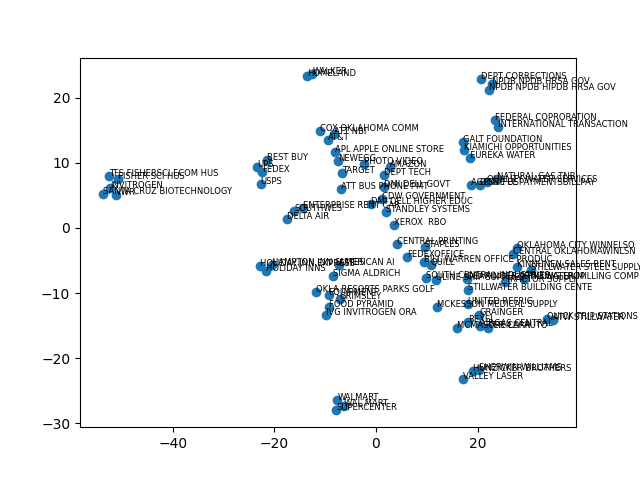

In [35]:
%matplotlib widget
x = embedded[:, 0]
y = embedded[:, 1]
tags = np.array(list(vendors_name_to_idx))

fig, ax = plt.subplots()
ax.scatter(x, y)

for i, txt in enumerate(tags):
    ax.annotate(txt, (x[i], y[i]), size=6)

plt.show()